Empirical coverage over 1000 runs: 0.9340


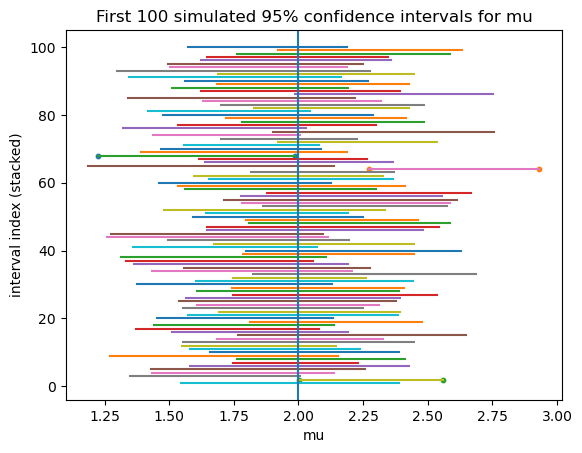

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# ----------------------------
# Simulation settings
# ----------------------------
rng = np.random.default_rng(0)

mu_true = 2.0
sigma_true = 1.0
n = 30                  # sample size per experiment
R = 1000               # number of repeated experiments
alpha = 0.05            # 95% CI

# ----------------------------
# Run repeated experiments
# ----------------------------
covers = np.empty(R, dtype=bool)
ci_low = np.empty(R)
ci_high = np.empty(R)

tcrit = t.ppf(1 - alpha/2, df=n-1)

for r in range(R):
    x = rng.normal(loc=mu_true, scale=sigma_true, size=n)
    xbar = x.mean()
    s = x.std(ddof=1)
    half_width = tcrit * s / np.sqrt(n)
    ci_low[r] = xbar - half_width
    ci_high[r] = xbar + half_width
    covers[r] = (ci_low[r] <= mu_true) and (mu_true <= ci_high[r])

coverage = covers.mean()
print(f"Empirical coverage over {R} runs: {coverage:.4f}")

# ----------------------------
# Visualize a subset of intervals
# ----------------------------
k = 100  # plot first 100 intervals
plt.figure()
for i in range(k):
    y = k - i  # just stack them
    plt.plot([ci_low[i], ci_high[i]], [y, y])
    # mark intervals that miss the truth
    if not covers[i]:
        plt.scatter([ci_low[i], ci_high[i]], [y, y], s=10)

plt.axvline(mu_true)
plt.title("First 100 simulated 95% confidence intervals for mu")
plt.xlabel("mu")
plt.ylabel("interval index (stacked)")
plt.show()


In [3]:
covers

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True,

In [6]:
a = {1, 2, 3}
b = {2}

a & b                # set intersection operator
# {2, 3}

a.intersection(b)    # method form
# {2, 3}
a

{1, 2, 3}

In [8]:
2+2

4

In [9]:
memo={}
# "26" -> (2,6),(26)
# "20" -> (20)
#         dfs(0)
#     /                 \
#   dfs(1)->reutrn 0   dfs(2)->return 1
def dfs(i):
    if i==len(s):
        return 1
    if s[i]=='0':
        return 0
    if i in memo:
        return memo[i]
    res=dfs(i+1)
    if i+1<len(s) and 10<=int(s[i:(i+2)])<=26:
        res+=dfs(i+2)
    memo[i]=res
    return res
s="121"
dfs(0)
print(memo)

{2: 1, 1: 2, 0: 3}


In [24]:
coins = [1,2,5]
amount = 11

memo={}
def dfs(i,remain):
    if remain==0:
        return 0
    if remain<0 or i==len(coins):
        return float('inf')
    if (i,remain) in memo:
        return memo[(i,remain)]
    skip=dfs(i+1,remain)
    take=dfs(i,remain-coins[i])
    if take!=float('inf'):
        skip=min(skip,take+1)
    memo[(i,remain)]=skip
    return skip
ans=dfs(0,amount)

In [2]:
!pip install striprtf

In [4]:
# pip install striprtf
from striprtf.striprtf import rtf_to_text

rtf_path = "Untitled.rtf"  # <-- change to your actual RTF filename

with open(rtf_path, "r", encoding="utf-8") as f:
    raw_rtf = f.read()

text = rtf_to_text(raw_rtf)

lines = [ln.strip() for ln in text.splitlines()]

total_interns = 0
num_hold = 0
num_accepted = 0

for i, line in enumerate(lines):
    # Adjust this predicate if your title string is slightly different
    if "Software Engineering Intern" in line:
        total_interns += 1

        # Look ahead for the first non-empty status line
        status = None
        for j in range(i + 1, len(lines)):
            if lines[j]:  # non-empty
                status = lines[j]
                break

        if status == "Leadership hold":
            num_hold += 1
        elif status == "Offer accepted":
            num_accepted += 1

print("Total intern positions:", total_interns)
print("On leadership hold:", num_hold)
print("Offer accepted:", num_accepted)
print("Other status (e.g., hiring in progress):", total_interns - num_hold - num_accepted)

Total intern positions: 951
On leadership hold: 517
Offer accepted: 408
Other status (e.g., hiring in progress): 26


In [15]:
from collections import defaultdict
words = ["wrt","wrf","er","ett","rftt"]
graph=defaultdict(set)
for i in range(len(words)-1):
    w1,w2=words[i],words[i+1]
    print(w1,w2)
    min_len=min(len(w1),len(w2))
    if len(w1)>len(w2) and w1[:min_len]==w2[:min_len]:
        break
    for j in range(min_len):
        if w1[j]!=w2[j]:
            graph[w2[j]].add(w1[j])
            break

wrt wrf
wrf er
er ett
ett rftt


In [7]:
edges=[[0,1],[2,3],[1,2]]
n=4
parent=[i for i in range(n)]
def find(x):
    if parent[x]!=x:
        return find(parent[x])
    else:
        return x
def union(x,y):
    rootX, rootY = find(x), find(y)
    parent[rootY]=rootX
for a,b in edges:
    union(a,b)
    print(a,b)
    print(parent)

0 1
[0, 0, 2, 3]
2 3
[0, 0, 2, 2]
1 2
[0, 0, 0, 2]


In [4]:
len({find(i) for i in range(n)})  # count unique roots

1

In [13]:
n=3
tests=[1,2,3]
mid = n // 2
left = tests[:mid]
right = tests[mid:]
print(left,right)


[1] [2, 3]
